In [70]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_recall_curve

# Make plots look nice
plt.style.use('seaborn-v0_8')

# Load the dataset
df = pd.read_csv('framingham.csv')

# Check target distribution
df.drop('education', axis=1, inplace=True)
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [71]:
# Separate features (X) and target (y)
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Fill any missing numeric values with column means
X.fillna(X.mean(), inplace=True)
print("Number of features used:", X.shape[1])

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

Number of features used: 14


In [72]:
# Standardize the numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1079
           1       0.27      0.50      0.36       193

    accuracy                           0.72      1272
   macro avg       0.59      0.63      0.59      1272
weighted avg       0.80      0.72      0.75      1272

Accuracy: 0.7232704402515723
Model Coefficients:
 male               0.242322
age                0.606965
currentSmoker      0.035160
cigsPerDay         0.263013
BPMeds             0.036037
prevalentStroke    0.067575
prevalentHyp       0.091072
diabetes           0.018849
totChol            0.065666
sysBP              0.260115
diaBP              0.045622
BMI                0.073968
heartRate         -0.044746
glucose            0.169943
dtype: float64


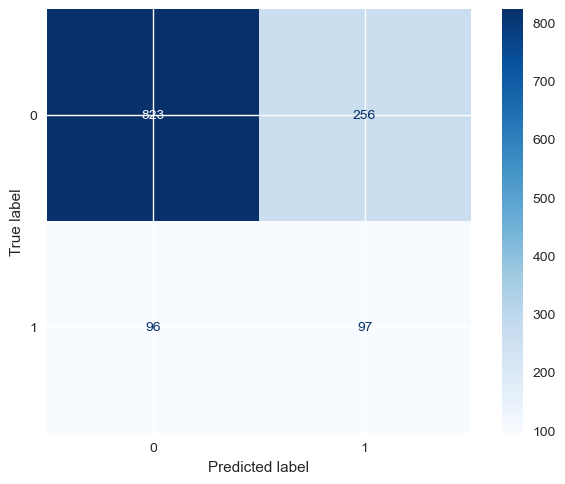

In [83]:
# Baseline model (to be improved)
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train)

# Predictions & probabilities
y_proba = model.predict_proba(X_test_scaled)[:, 1]
threshold = 0.58
y_pred = (y_proba >= threshold).astype(int)


# Evaluation metrics
confusion = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=confusion)
display.plot(cmap=plt.cm.Blues)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = (y_pred == y_test).mean()
print("Accuracy:", accuracy)

coefficients = pd.Series(model.coef_[0], index=X.columns)
print("Model Coefficients:\n", coefficients)